In [2]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/maimunarahma/ai-ml/main/DecisionTree/heart.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
df.fillna(df.mean(), inplace=True)

In [4]:
from sklearn.tree import DecisionTreeClassifier

cart = DecisionTreeClassifier(criterion="gini")

In [5]:
from sklearn.model_selection import train_test_split

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [6]:
from sklearn.model_selection import GridSearchCV

params = {
    "max_depth": [3,5,7,10],
    "min_samples_split": [2,5,10]
}

grid_cart = GridSearchCV(cart, params, cv=5)
grid_cart.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': [3, 5, 7, 10],
                         'min_samples_split': [2, 5, 10]})

In [7]:
id3 = DecisionTreeClassifier(criterion="entropy")

In [8]:
grid_id3 = GridSearchCV(id3, params, cv=5)
grid_id3.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(criterion='entropy'),
             param_grid={'max_depth': [3, 5, 7, 10],
                         'min_samples_split': [2, 5, 10]})

## 3. Required Visualizations (2x1 Comparison)

In [9]:
# Get the best models from GridSearchCV
best_cart_model = grid_cart.best_estimator_
best_id3_model = grid_id3.best_estimator_

print("Best CART Model Parameters:", grid_cart.best_params_)
print("Best ID3 Model Parameters:", grid_id3.best_params_)

Best CART Model Parameters: {'max_depth': 10, 'min_samples_split': 2}
Best ID3 Model Parameters: {'max_depth': 10, 'min_samples_split': 2}


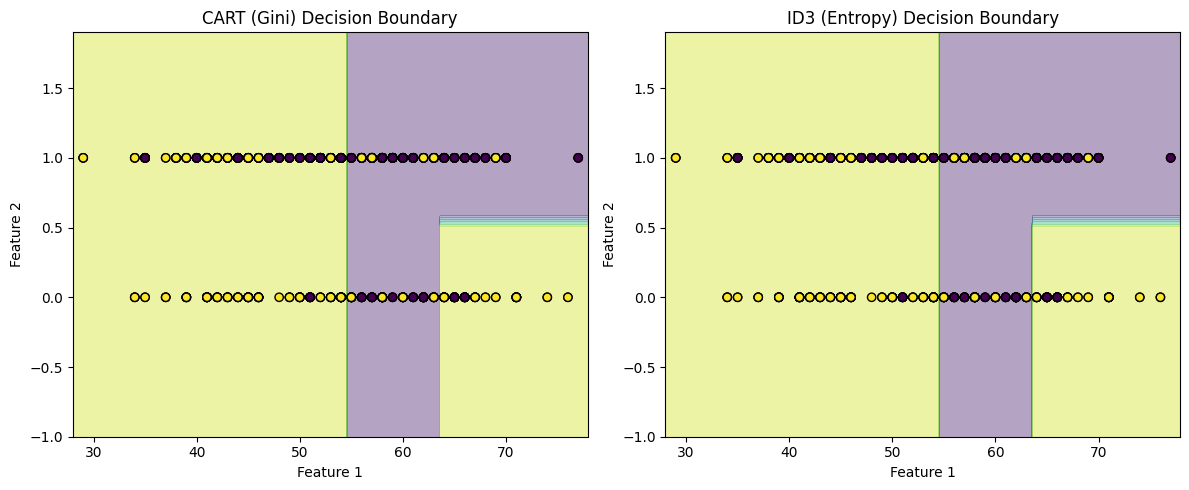

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

# =========================
# STEP 1: Use only 2 features (IMPORTANT)
# =========================
# Convert to DataFrame slicing (fixes your error)
X_2d = X_train.iloc[:, :2].values
y_2d = y_train.values

# =========================
# STEP 2: Train CART (Gini)
# =========================
cart_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)
cart_model.fit(X_2d, y_2d)

# =========================
# STEP 3: Train ID3 (Entropy)
# =========================
id3_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    random_state=42
)
id3_model.fit(X_2d, y_2d)

# =========================
# STEP 4: Create mesh grid
# =========================
x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.1),
    np.arange(y_min, y_max, 0.1)
)

grid = np.c_[xx.ravel(), yy.ravel()]

# =========================
# STEP 5: Predictions for boundary
# =========================
Z_cart = cart_model.predict(grid).reshape(xx.shape)
Z_id3 = id3_model.predict(grid).reshape(xx.shape)

# =========================
# STEP 6: Plot 2x1 Decision Boundary
# =========================
plt.figure(figsize=(12,5))

# -------- CART --------
plt.subplot(1,2,1)
plt.contourf(xx, yy, Z_cart, alpha=0.4)
plt.scatter(X_2d[:,0], X_2d[:,1], c=y_2d, edgecolor='k')
plt.title("CART (Gini) Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

# -------- ID3 --------
plt.subplot(1,2,2)
plt.contourf(xx, yy, Z_id3, alpha=0.4)
plt.scatter(X_2d[:,0], X_2d[:,1], c=y_2d, edgecolor='k')
plt.title("ID3 (Entropy) Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.tight_layout()
plt.show()

### 2. Confusion Matrix (2x1 Matrix)

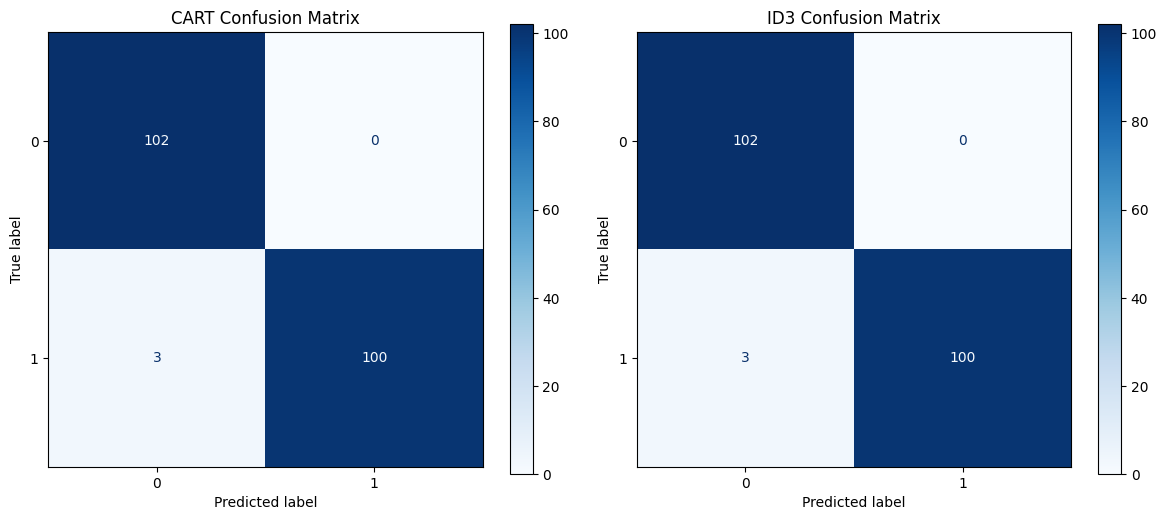

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Predict on the test set
y_pred_cart = best_cart_model.predict(X_test)
y_pred_id3 = best_id3_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot Confusion Matrix for CART
ConfusionMatrixDisplay.from_estimator(best_cart_model, X_test, y_test, cmap=plt.cm.Blues, ax=axes[0])
axes[0].set_title('CART Confusion Matrix')

# Plot Confusion Matrix for ID3
ConfusionMatrixDisplay.from_estimator(best_id3_model, X_test, y_test, cmap=plt.cm.Blues, ax=axes[1])
axes[1].set_title('ID3 Confusion Matrix')

plt.tight_layout()
plt.show()

### 3. ROC Curve (2x1 Matrix)

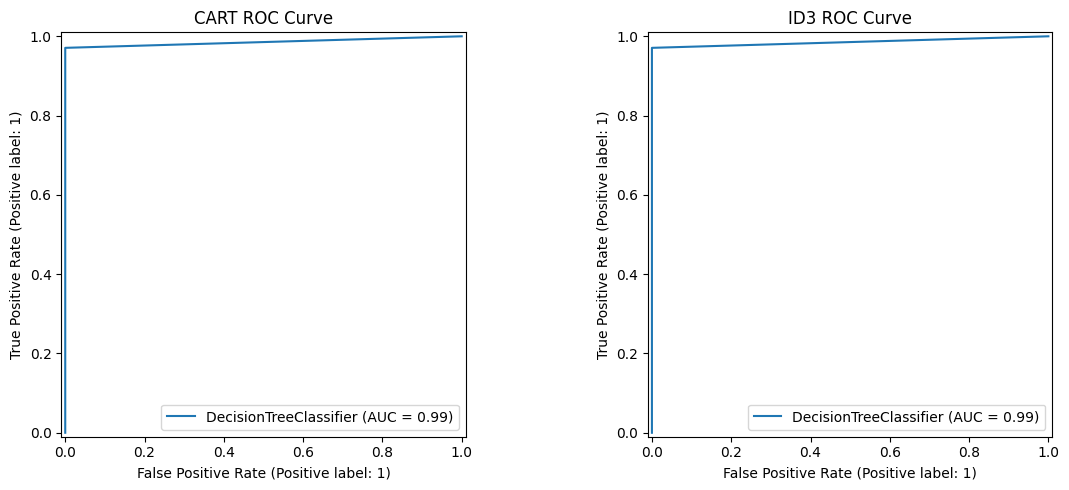

In [13]:
from sklearn.metrics import RocCurveDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot ROC Curve for CART
RocCurveDisplay.from_estimator(best_cart_model, X_test, y_test, ax=axes[0])
axes[0].set_title('CART ROC Curve')

# Plot ROC Curve for ID3
RocCurveDisplay.from_estimator(best_id3_model, X_test, y_test, ax=axes[1])
axes[1].set_title('ID3 ROC Curve')

plt.tight_layout()
plt.show()

### 4. Evaluation Metrics (Combined Bar Chart)

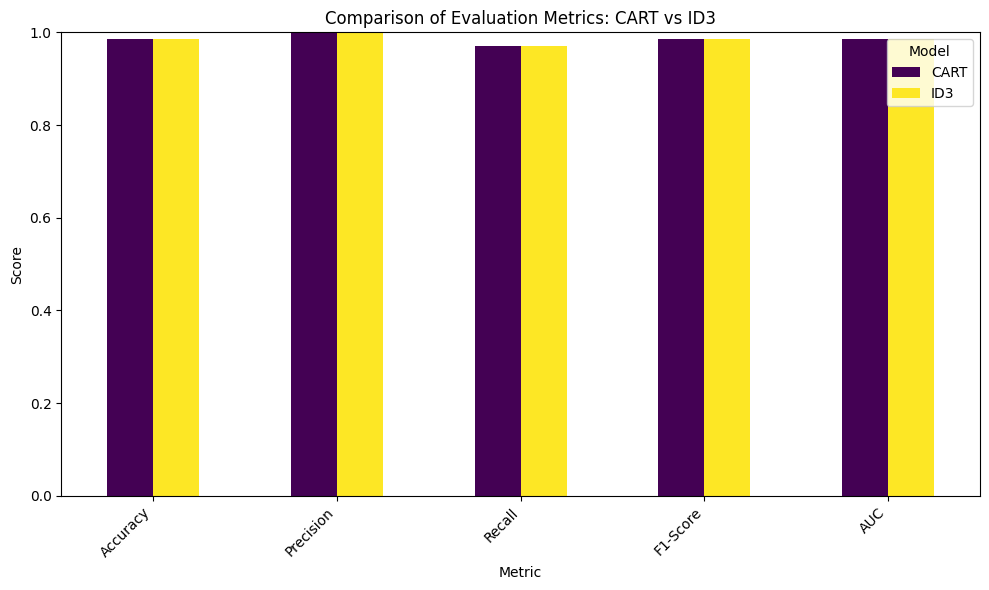

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
import numpy as np

# Calculate metrics for CART
accuracy_cart = accuracy_score(y_test, y_pred_cart)
precision_cart = precision_score(y_test, y_pred_cart)
recall_cart = recall_score(y_test, y_pred_cart)
f1_cart = f1_score(y_test, y_pred_cart)
auc_cart = roc_auc_score(y_test, best_cart_model.predict_proba(X_test)[:, 1])

# Calculate metrics for ID3
accuracy_id3 = accuracy_score(y_test, y_pred_id3)
precision_id3 = precision_score(y_test, y_pred_id3)
recall_id3 = recall_score(y_test, y_pred_id3)
f1_id3 = f1_score(y_test, y_pred_id3)
auc_id3 = roc_auc_score(y_test, best_id3_model.predict_proba(X_test)[:, 1])

metrics_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC'],
    'CART': [accuracy_cart, precision_cart, recall_cart, f1_cart, auc_cart],
    'ID3': [accuracy_id3, precision_id3, recall_id3, f1_id3, auc_id3]
}
metrics_df = pd.DataFrame(metrics_data)

# Plotting the combined bar chart
fig, ax = plt.subplots(figsize=(10, 6))

metrics_df.plot(x='Metric', y=['CART', 'ID3'], kind='bar', ax=ax, colormap='viridis')
ax.set_title('Comparison of Evaluation Metrics: CART vs ID3')
ax.set_ylabel('Score')
ax.set_ylim(0, 1) # Metrics are typically between 0 and 1
plt.xticks(rotation=45, ha='right')
plt.legend(title='Model')
plt.tight_layout()
plt.show()

### 5. DT Structure (Visualization of optimized tree structure)

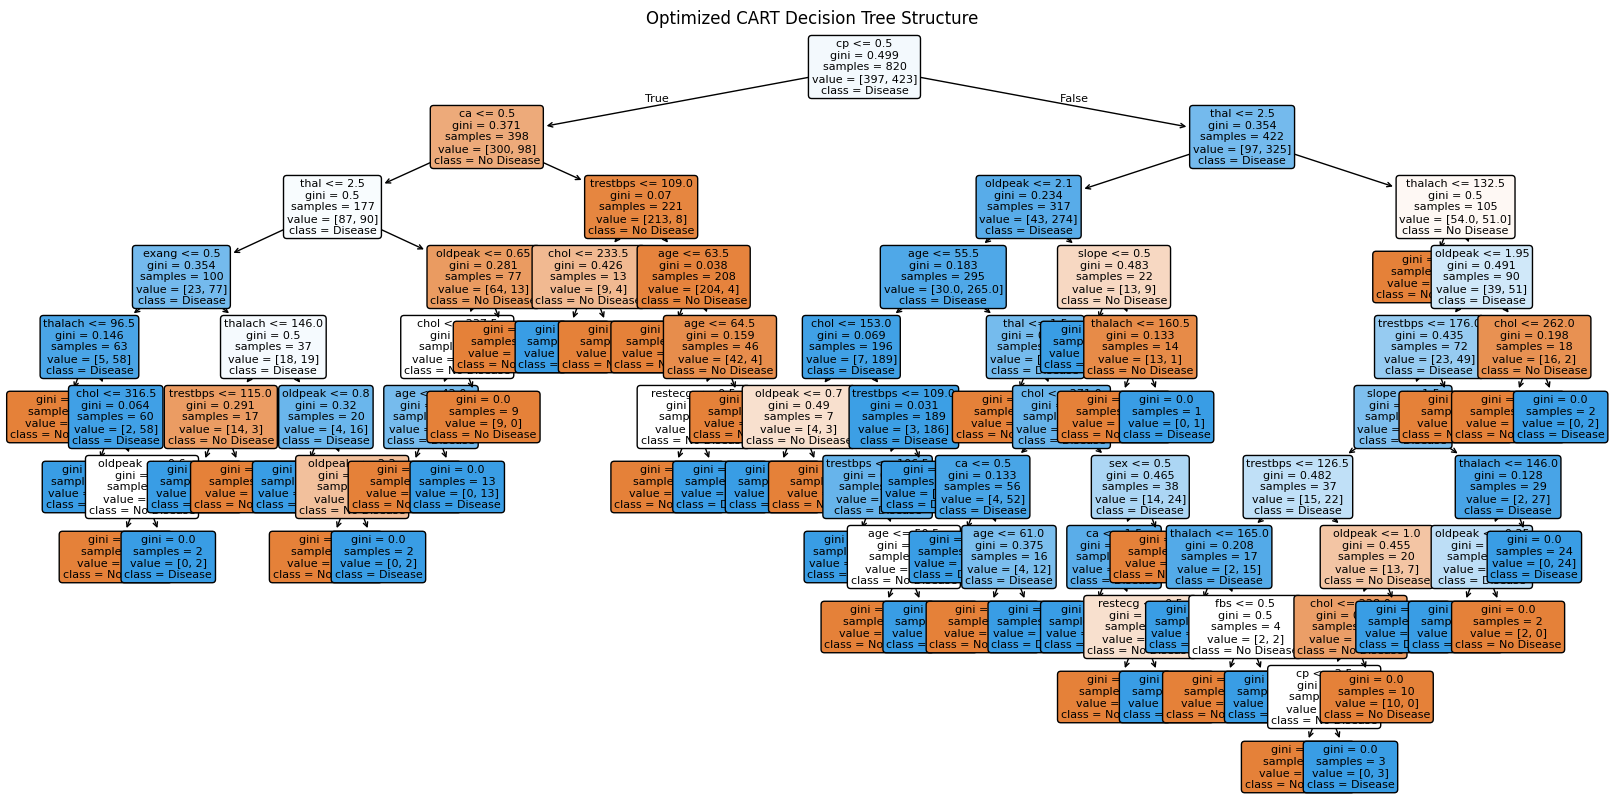

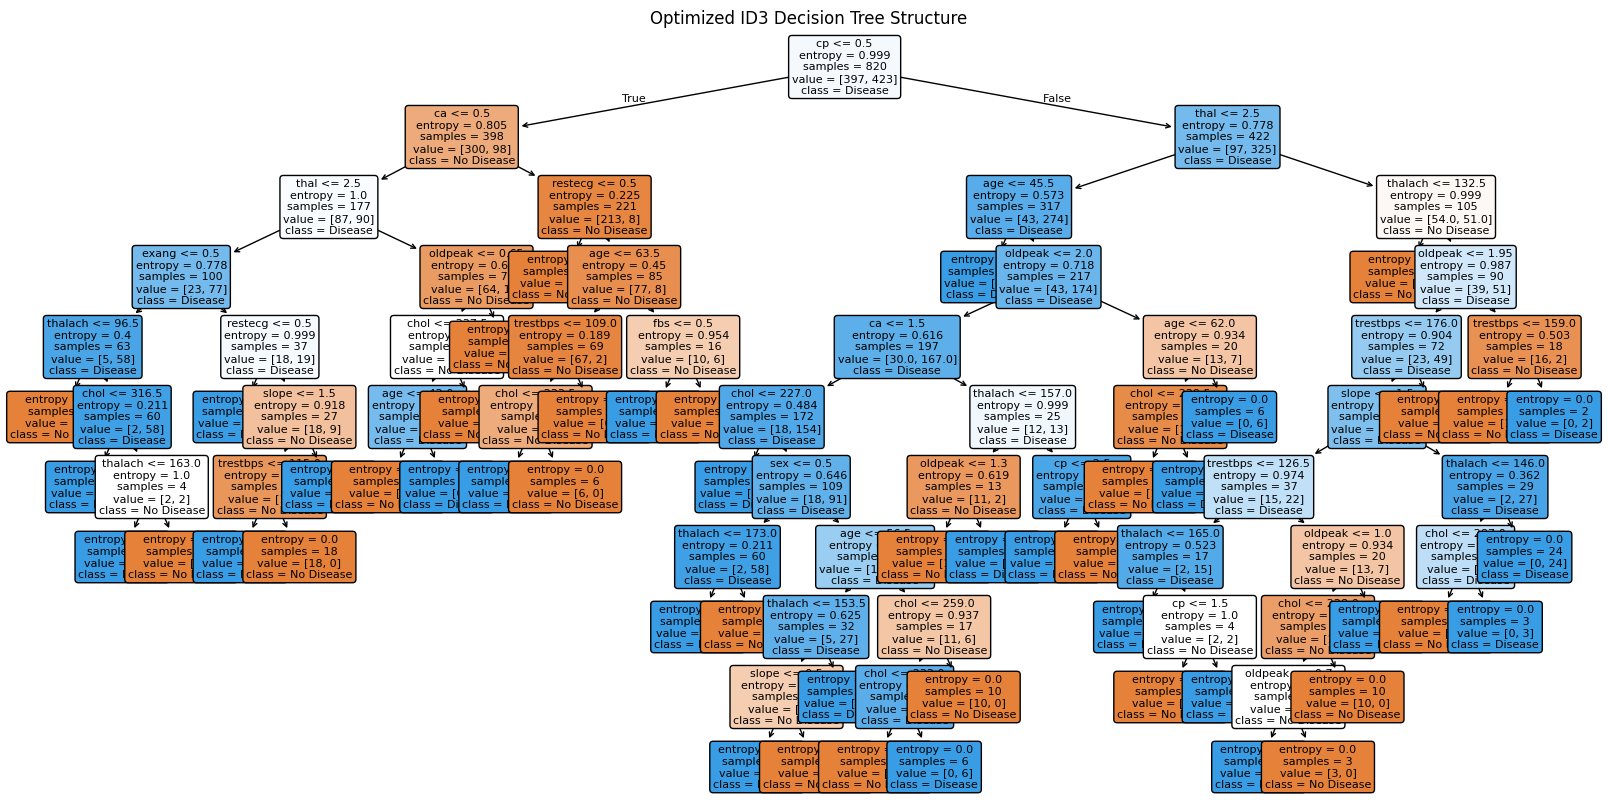

In [15]:
from sklearn.tree import plot_tree

# Visualize the CART Decision Tree
plt.figure(figsize=(20, 10))
plot_tree(best_cart_model, feature_names=X.columns.tolist(), class_names=['No Disease', 'Disease'], filled=True, rounded=True, fontsize=8)
plt.title('Optimized CART Decision Tree Structure')
plt.show()

# Visualize the ID3 Decision Tree
plt.figure(figsize=(20, 10))
plot_tree(best_id3_model, feature_names=X.columns.tolist(), class_names=['No Disease', 'Disease'], filled=True, rounded=True, fontsize=8)
plt.title('Optimized ID3 Decision Tree Structure')
plt.show()

In [16]:
X = df.drop('target', axis=1)
y = df['target']

# Identify categorical columns for one-hot encoding (excluding the target column)
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
print("X_train head:")
display(X_train.head())
print("X_train shape:", X_train.shape)

print("\nX_test head:")
display(X_test.head())
print("X_test shape:", X_test.shape)

X_train head:


,age,trestbps,chol,thalach,oldpeak,sex_1,cp_1,cp_2,cp_3,fbs_1,...,exang_1,slope_1,slope_2,ca_1,ca_2,ca_3,ca_4,thal_1,thal_2,thal_3
835,49,118,149,126,0.8,True,False,True,False,False,...,False,False,True,False,False,True,False,False,True,False
137,64,180,325,154,0.0,False,False,False,False,False,...,True,False,True,False,False,False,False,False,True,False
534,54,108,267,167,0.0,False,False,True,False,False,...,False,False,True,False,False,False,False,False,True,False
495,59,135,234,161,0.5,True,False,False,False,False,...,False,True,False,False,False,False,False,False,False,True
244,51,125,245,166,2.4,True,False,True,False,True,...,False,True,False,False,False,False,False,False,True,False


X_train shape: (820, 22)

X_test head:


,age,trestbps,chol,thalach,oldpeak,sex_1,cp_1,cp_2,cp_3,fbs_1,...,exang_1,slope_1,slope_2,ca_1,ca_2,ca_3,ca_4,thal_1,thal_2,thal_3
527,62,124,209,163,0.0,False,False,False,False,False,...,False,False,True,False,False,False,False,False,True,False
359,53,128,216,115,0.0,False,False,True,False,False,...,False,False,True,False,False,False,False,False,False,False
447,55,160,289,145,0.8,True,False,False,False,False,...,True,True,False,True,False,False,False,False,False,True
31,50,120,244,162,1.1,False,True,False,False,False,...,False,False,True,False,False,False,False,False,True,False
621,48,130,256,150,0.0,True,False,False,False,True,...,True,False,True,False,True,False,False,False,False,True


X_test shape: (205, 22)
